# Introduction

The goal of this notebook is to test various agents in a simple Blackjack enviroment, and track their performance across 1 million games.

### Blackjack rules used:
- Player's allowed **actions** are [$hit = 0$] and [$stay = 1$].
- Player's possible **rewards** each round are [$-1$, $0$, $1$, $1.5$] with $1.5$ reward occuring when the player has blackjack and dealer doesn't.
- Dealer **stays** on both *soft* and *hard* $17$.

# Imports

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from enviroment import Blackjack
from agents import RandomAgent, HitUntilSeventeenAgent, QlearningAgent, QGreedyAgent
from utils import run_simulation, run_simulation_q, show_results, show_prints, show_agent_policy, show_q_agent_counter

# Available Agents

All available agents exist in **agents.py**.\
You can create your own agent in that file, make sure to define an action(state) function.

## 1) Random Agent

Acts randomly for all states.

## 2) Hit Until 17 Agent

Selects action **Hit** if player total is less than $17$ else action **Stay**.

## 3) Q Learning Agent


### Enviroment states to Agent index states:

**Player Total**: $\{4, 5, ..., 21\} \rightarrow \{0, 1, ..., 17\}$

**Dealer Upcard**: $\{1, 2, ..., 13\} \rightarrow \{0, 1, ..., 9\}$

**Usable Ace**: $\{False,\ True\} \rightarrow \{0, 1\}$

### Agent details:

**Hyperparameters**

- alpha ($a$): Learning Rate
- epsilon ($e$) : Exploring probability
- gamma ($g$) : Discounting Factor

**Q-table Update Equation**
- $target \leftarrow reward\ $ if (game is not done) else $\ reward + g\cdot Q(s_{new})$
- $Q(s) \leftarrow Q(s) + a\cdot(target - Q(s))$


# Experiments

## Non-Learning Agents

The following parameters can be edited with indicated possible values:
- **num_rounds** $\ $ (positive integer)
- **agent** $\ $ (RandomAgent(), HitUntilSeventeenAgent())

=======================  RESULTS  =======================
Total Rounds: 1000000
Final Reward: -55291.00$
Average Reward per Round: -0.0553$
Winrate: 0.4123  ||  Drawrate: 0.0973  ||  Lossrate: 0.4904
Agent: HitUntilSeventeenAgent


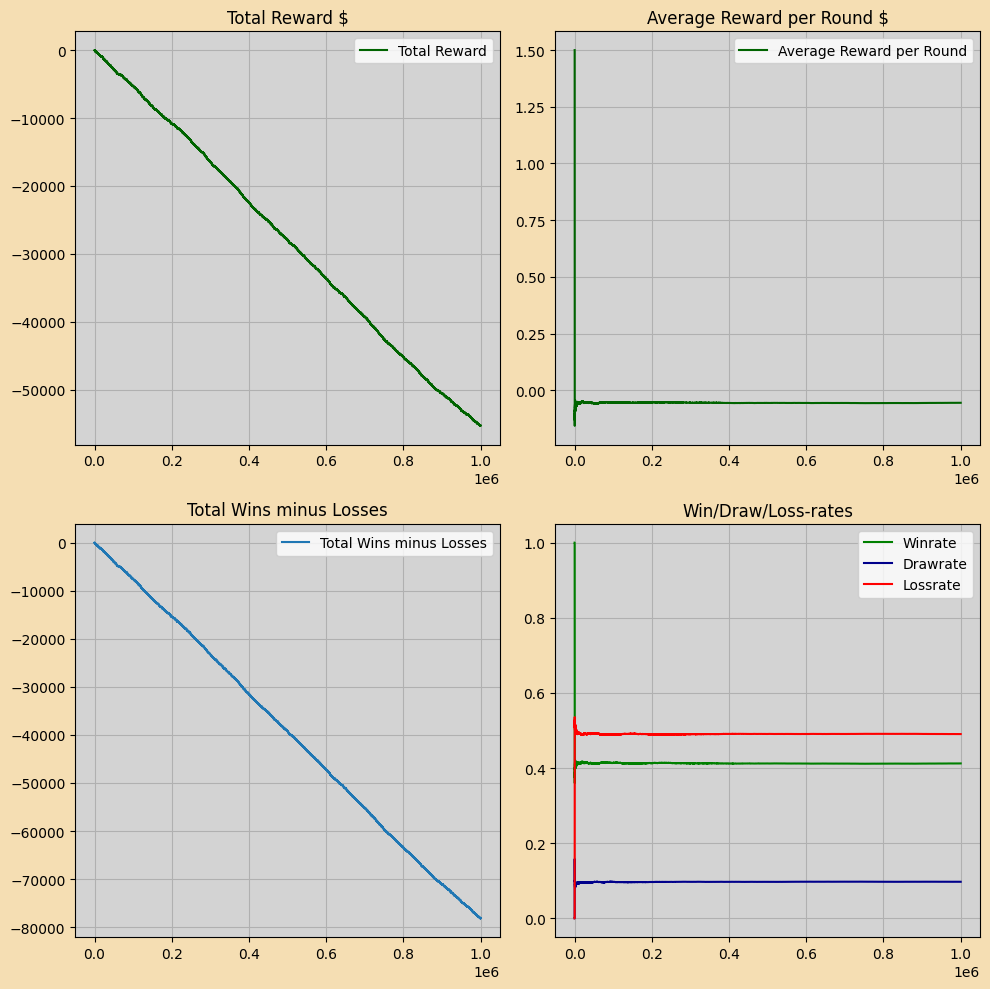

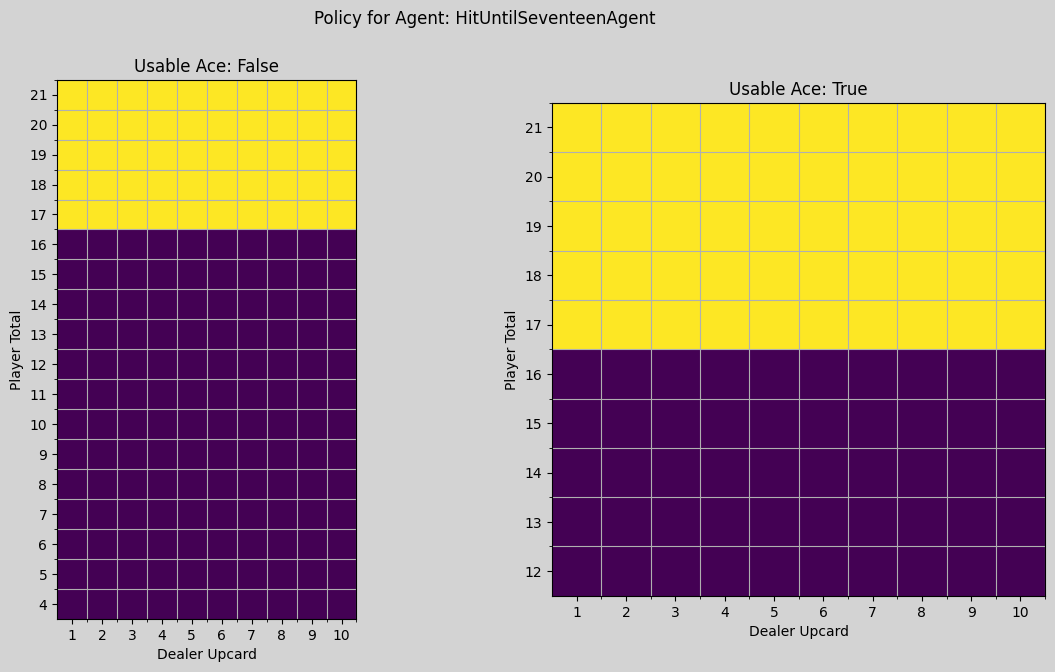

In [2]:
#======================================== START ========================================#

num_rounds = 1000000
agent = HitUntilSeventeenAgent()

#========================================= END =========================================#


history = run_simulation(num_rounds, agent)
show_prints(history)
print(f'Agent: {agent.__class__.__name__}')
show_results(history)
show_agent_policy(agent)

## Q-Learning Agent

The following parameters can be edited with indicated possible values:
- **num_rounds** $\ $ (positive integer)
- **n_step_estimate** $\ $ Estimate of expected number of steps per round, it currently affects $a$ and $e$ schedule.
- **agent_params** $(a, e, g)\ $ Hyperparameters for the agent - $a, e$ are lists and $g$ is constant\
They are currently defined with a custom hyperbolic schedule, feel free to modify or create your own schedule!

=======================  RESULTS  =======================
Total Rounds: 1000000
Final Reward: -50818.50$
Average Reward per Round: -0.0508$
Winrate: 0.4208  ||  Drawrate: 0.0848  ||  Lossrate: 0.4944


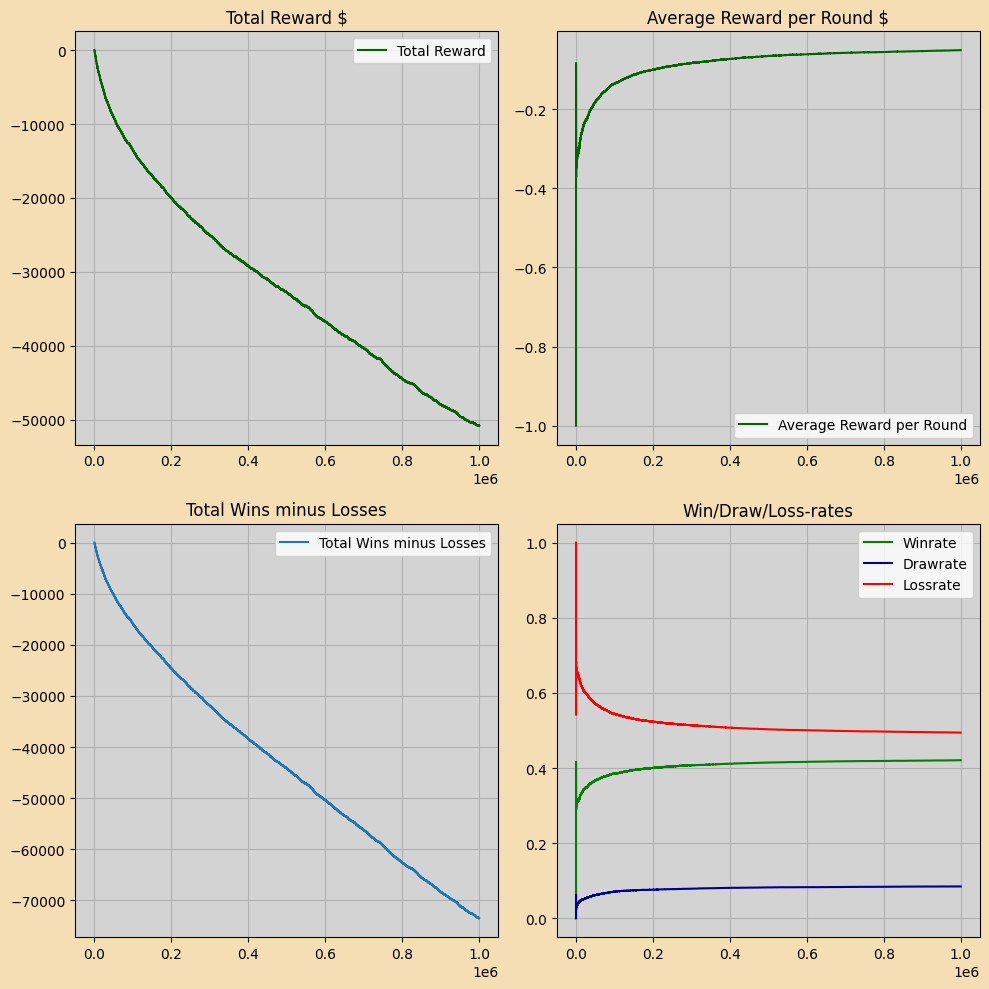

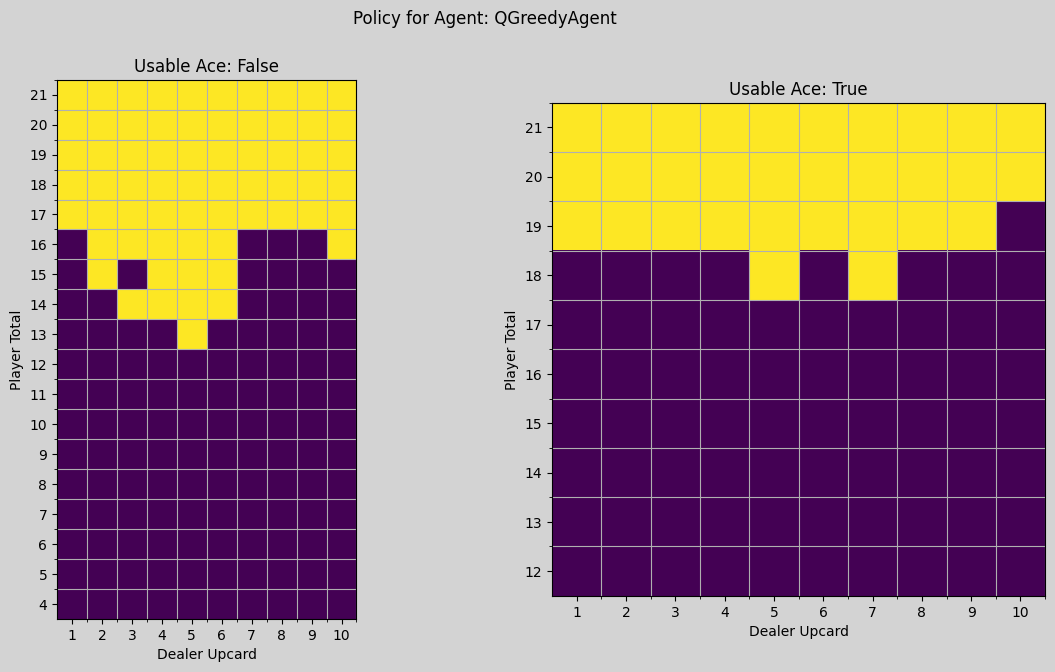

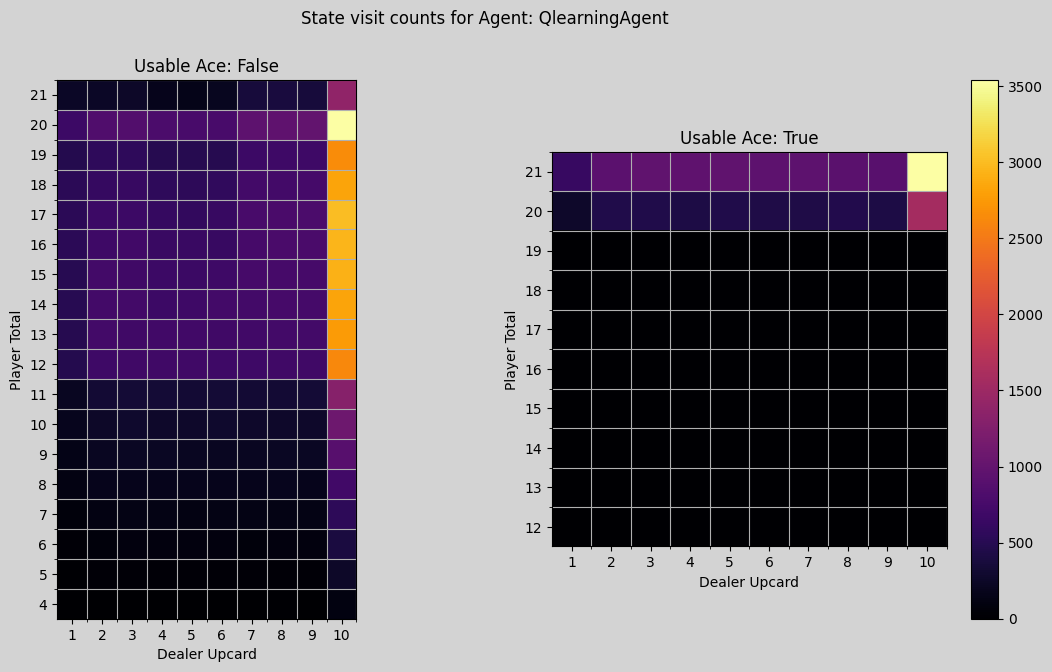

In [3]:
#======================================== START ========================================#

num_rounds = 1000000
c = 1.45
n_step_estimate = int(c * num_rounds)
h_alpha = n_step_estimate / 100
h_epsilon = n_step_estimate / 100

hyperbolic_schedule = lambda x, h : 1 / (1 + (x / h))
linear_schedule = lambda x, n : 1 - (1 + x) / n 
basic_range = np.concatenate([np.arange(n_step_estimate), (n_step_estimate - 1) * np.ones(5 * n_step_estimate)])

agent_params = {
    'alpha': hyperbolic_schedule(basic_range, h_alpha),
    'epsilon': hyperbolic_schedule(basic_range, h_epsilon),
    'gamma': 1
}
#========================================= END =========================================#

q_agent = QlearningAgent(agent_params)
history = run_simulation_q(num_rounds, q_agent)
greedy_q_agent = QGreedyAgent(q_agent)

show_prints(history)
show_results(history)
show_agent_policy(greedy_q_agent)
show_q_agent_counter(q_agent)